<a href="https://colab.research.google.com/github/Issam-Allymis/BootstrapProjectCI/blob/master/superstore-sales-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import os
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
print(os.listdir(path))

100%|██████████| 550k/550k [00:00<00:00, 1.33MB/s]

Extracting files...
['Sample - Superstore.csv']


In [2]:
import pandas as pd

df = pd.read_csv(path+"/Sample - Superstore.csv", encoding='latin1')

df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### Hypothesis
I expect that higher discounts negatively impact profitability, meaning that as discount levels increase, profit will decrease.

In [4]:
df.groupby('Category')[['Sales', 'Profit']].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


### Insight
Technology is the high performing category, generating both the highest sales and profit.
However Furniture shows high sales but very low profit, indicating potential issues with costs or heavy discounting. This suggests that while Furniture drives revenue, it may not be contributing effectively to overall profitability.
Office Supplies, while generating slightly lower sales, delivers strong profit, indidcating more efficient pricing or cost control.

### Hypothesis
I believe that higher discounts negatively affect profitability, meaning that as discounts levels increase the profit decreases. making them negatively correlated.

In [5]:
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [15]:
grouped = df.groupby('Discount')['Profit'].mean()
grouped

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


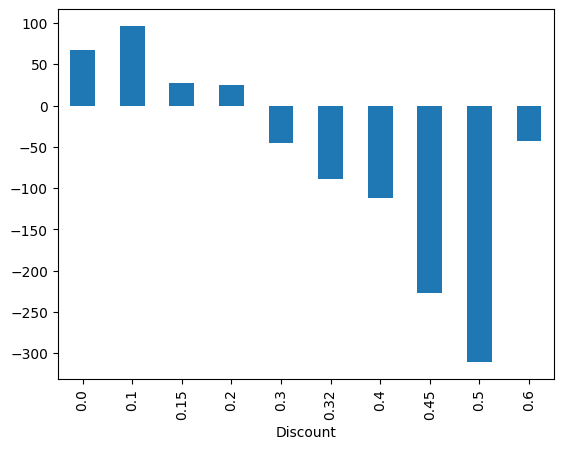

In [13]:
grouped.sort_index().head(10).plot(kind='bar', x='Profit', y='Discount')
plt.show()

In [17]:
df.groupby('Category')['Discount'].mean()

,Discount
Category,
Furniture,0.173923
Office Supplies,0.157285
Technology,0.132323


### Insight
The analysis shows that as discounts levels increase, profitability decreases significantly. While low discounts (0-20%) still generates positive profit, higher levels (>30%) results in negative profit.
This suggests that excessive discounts is negatively affecting the business, as products are being sold at a loss. The comapny should reconsider its discount strategy to avoid a drop in profitability.

- **Furniture** generates high sales but relatively low profit compared to other categories. Further analysis shows that furniture has the highest average discount among all categories. Since higher discounts are associated with lower profitability, this suggests that excessive discounting in the furniture category is a key factor why profiatbility performance is poor. Reducing discount levels in furniture overall will reduce profit losses significantly and increase profits.

## Conclusion
The analysis shows that while some categories generate strong profit, others suffer due to excessive discounts which in hte long run is hurting the business. A Strategy change is needed to see improvments in business perfomance, especially The Furniture category.